In [1]:
# 1. Project Introduction
"""
This notebook analyzes daily volatility for four major global equity indices using GARCH(1,1) models.

Indices: S&P 500 (^GSPC), EURO STOXX 50 (^STOXX50E), Nikkei 225 (^N225), FTSE 100 (^FTSE)

Goals:
- Understand return behavior and volatility clustering across markets
- Estimate and compare conditional volatility via GARCH(1,1)
- Compare volatility persistence (alpha + beta) across global indices
- Evaluate model fit using AIC/BIC and residual diagnostics
"""

'\nThis notebook analyzes daily volatility for four major global equity indices using GARCH(1,1) models.\n\nIndices: S&P 500 (^GSPC), EURO STOXX 50 (^STOXX50E), Nikkei 225 (^N225), FTSE 100 (^FTSE)\n\nGoals:\n- Understand return behavior and volatility clustering across markets\n- Estimate and compare conditional volatility via GARCH(1,1)\n- Compare volatility persistence (alpha + beta) across global indices\n- Evaluate model fit using AIC/BIC and residual diagnostics\n'

In [2]:
# 2. Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
# 3. Load Data
INDICES = {
    'S&P 500':       '^GSPC',
    'EURO STOXX 50': '^STOXX50E',
    'Nikkei 225':    '^N225',
    'FTSE 100':      '^FTSE',
}
start_date = '2015-01-01'
end_date   = '2026-06-21'

raw = {}
for name, ticker in INDICES.items():
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level='Ticker')
    raw[name] = df[['Close']].dropna()
    print(f'{name} ({ticker}): {len(raw[name])} rows')

S&P 500 (^GSPC): 2882 rows
EURO STOXX 50 (^STOXX50E): 2878 rows
Nikkei 225 (^N225): 2800 rows
FTSE 100 (^FTSE): 2895 rows


In [4]:
# 4. Clean Data
data = {}
for name, df in raw.items():
    d = df.copy()
    d.index = pd.to_datetime(d.index)
    d = d.sort_index()
    d['log_return'] = np.log(d['Close']).diff()
    d['return_pct'] = d['log_return'] * 100  # scaled for GARCH estimation
    d = d.dropna()
    data[name] = d

# Summary statistics for returns
stats = pd.DataFrame({
    name: df['return_pct'].describe()
    for name, df in data.items()
}).round(4)
print('=== Return Summary Statistics ===')
print(stats)

=== Return Summary Statistics ===
         S&P 500  EURO STOXX 50  Nikkei 225   FTSE 100
count  2881.0000      2877.0000   2799.0000  2894.0000
mean      0.0449         0.0255      0.0503     0.0159
std       1.1227         1.2012      1.3527     0.9701
min     -12.7652       -13.2405    -13.2341   -11.5117
25%      -0.3805        -0.5208     -0.5946    -0.4260
50%       0.0703         0.0593      0.0787     0.0606
75%       0.5786         0.6223      0.7291     0.5036
max       9.0895         8.8343      9.7366     8.6664


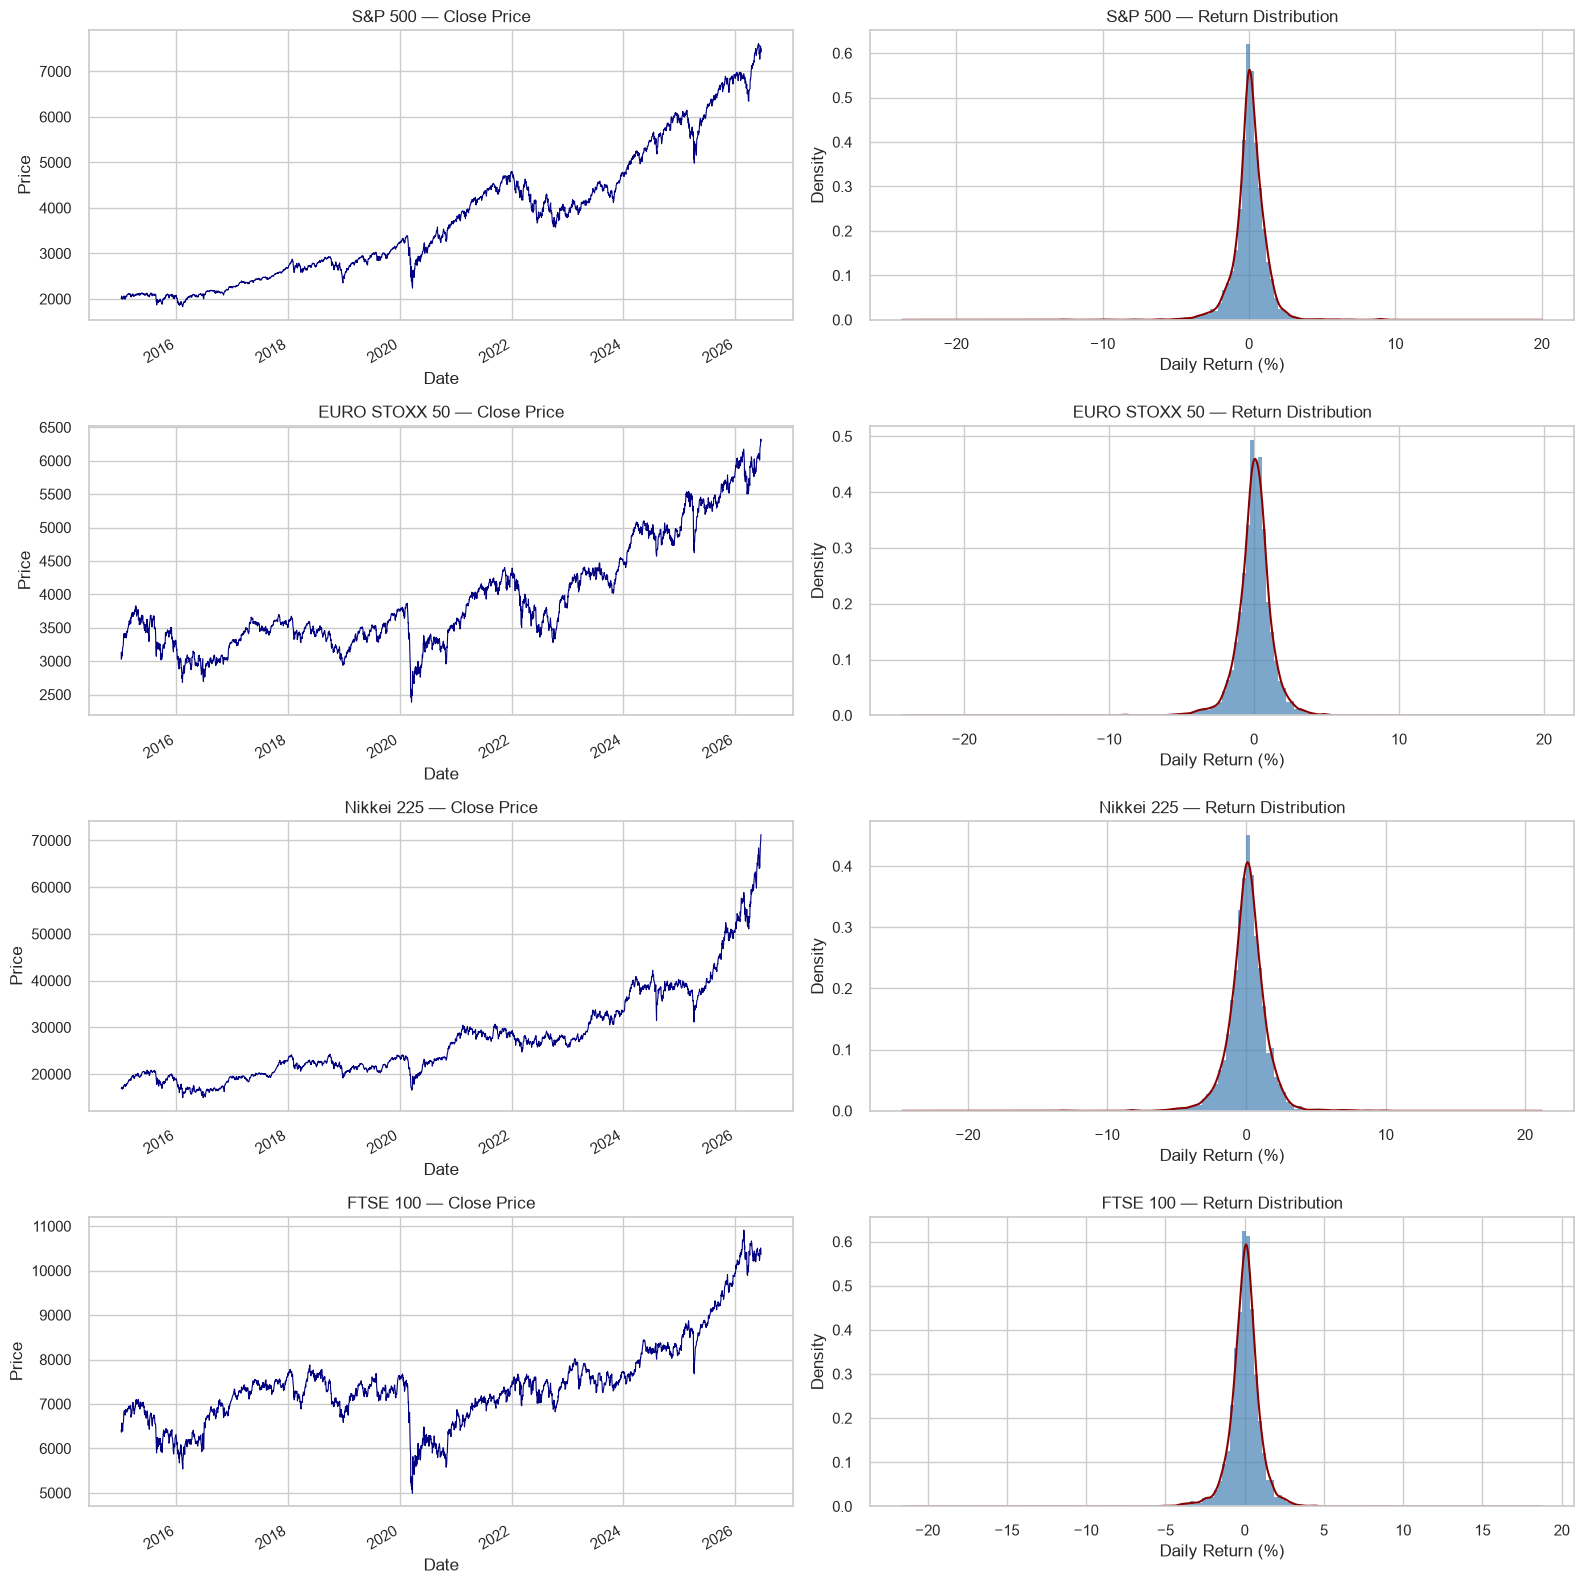

In [5]:
# 5. Exploratory Data Analysis
fig, axes = plt.subplots(len(data), 2, figsize=(16, 4 * len(data)))

for i, (name, df) in enumerate(data.items()):
    df['Close'].plot(ax=axes[i, 0], color='navy', linewidth=0.8)
    axes[i, 0].set_title(f'{name} — Close Price')
    axes[i, 0].set_ylabel('Price')

    axes[i, 1].hist(df['return_pct'], bins=80, color='steelblue',
                    edgecolor='none', density=True, alpha=0.7)
    df['return_pct'].plot.kde(ax=axes[i, 1], color='darkred', linewidth=1.5)
    axes[i, 1].set_title(f'{name} — Return Distribution')
    axes[i, 1].set_xlabel('Daily Return (%)')
    axes[i, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

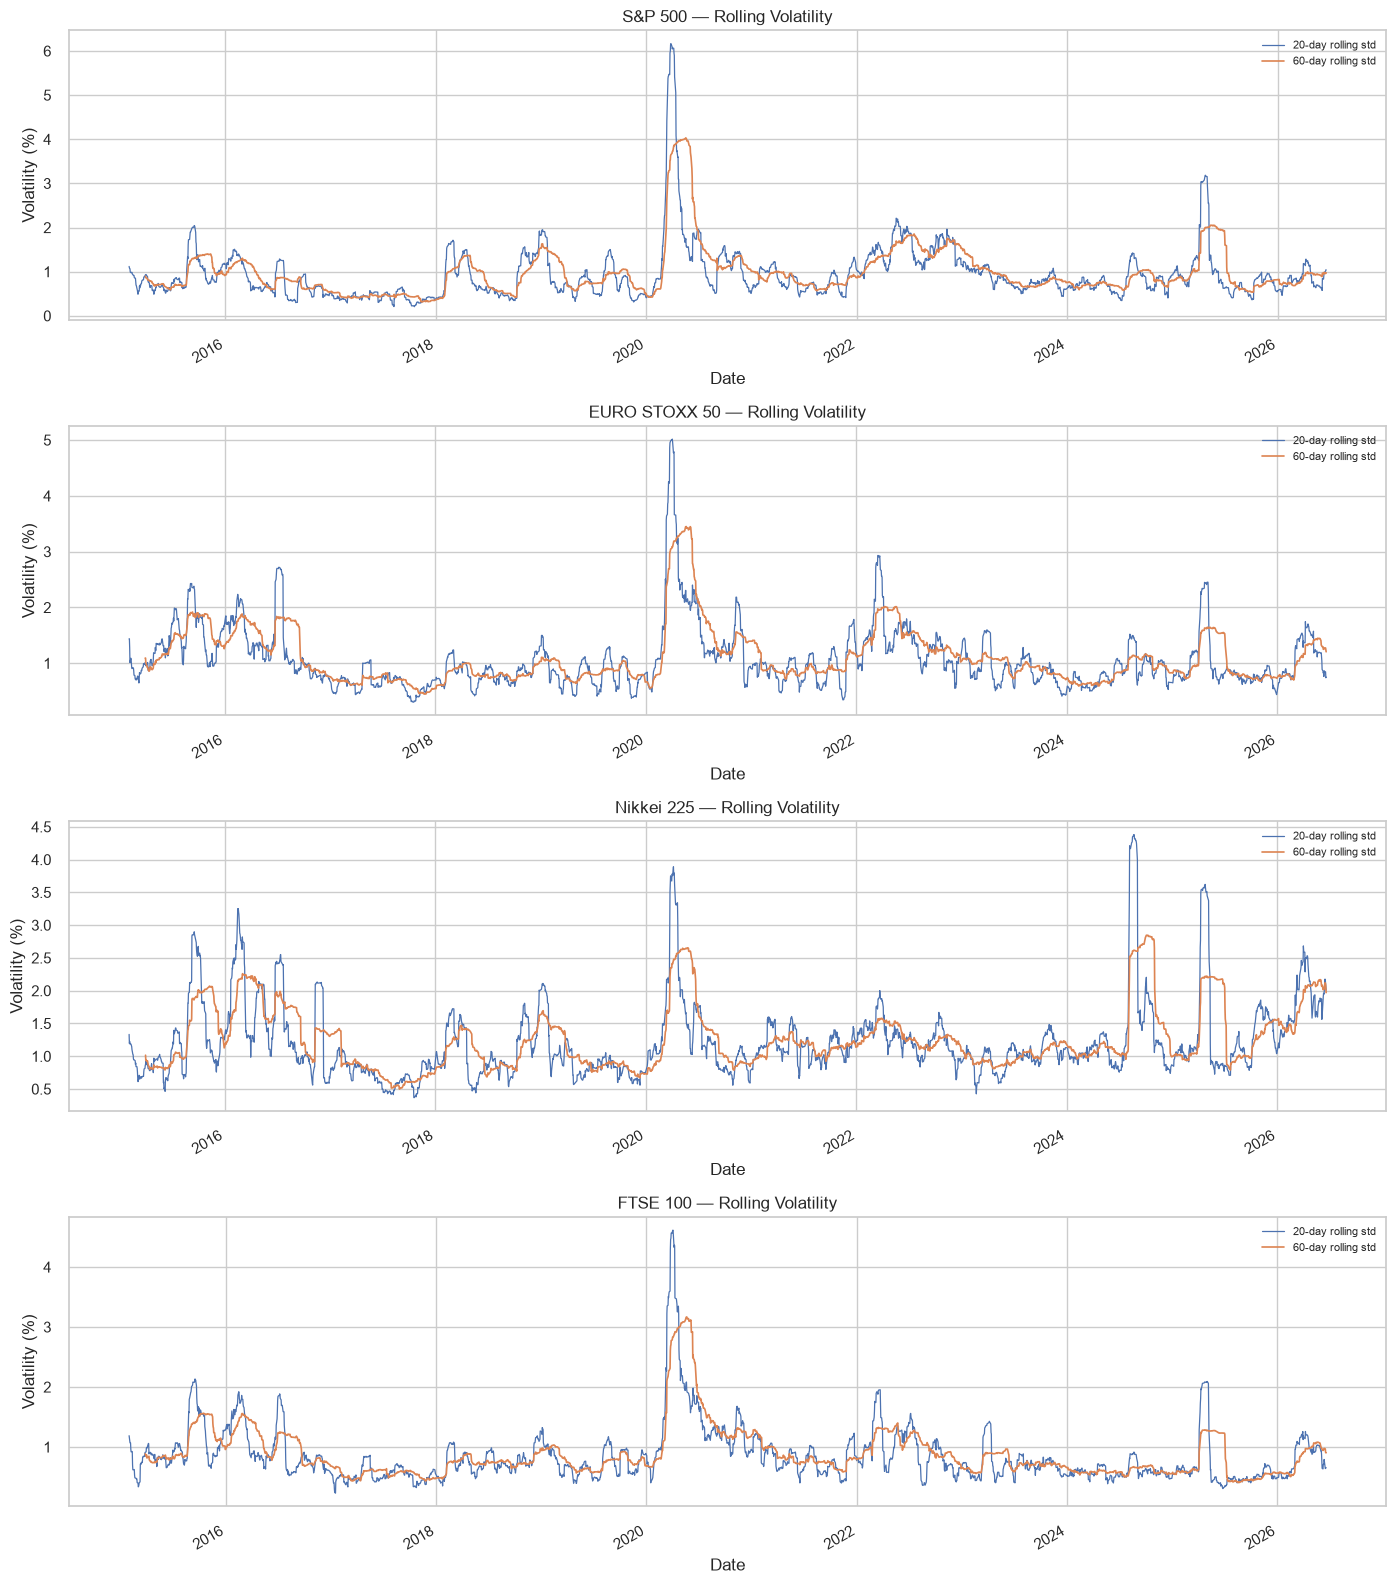

In [6]:
# 6. Feature Engineering — Rolling Volatility
fig, axes = plt.subplots(len(data), 1, figsize=(14, 4 * len(data)), sharex=False)

for i, (name, df) in enumerate(data.items()):
    df['rolling_vol_20'] = df['return_pct'].rolling(20).std()
    df['rolling_vol_60'] = df['return_pct'].rolling(60).std()

    df['rolling_vol_20'].plot(ax=axes[i], label='20-day rolling std', linewidth=0.9)
    df['rolling_vol_60'].plot(ax=axes[i], label='60-day rolling std', linewidth=1.2)
    axes[i].set_title(f'{name} — Rolling Volatility')
    axes[i].set_ylabel('Volatility (%)')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# 7. Model Building — GARCH(1,1) per Index
results = {}
for name, df in data.items():
    model = arch_model(df['return_pct'], vol='Garch', p=1, q=1, dist='Normal')
    res = model.fit(disp='off')
    results[name] = res
    print(f'\n=== {name} ===')
    print(res.summary())


=== S&P 500 ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3728.58
Distribution:                  Normal   AIC:                           7465.17
Method:            Maximum Likelihood   BIC:                           7489.03
                                        No. Observations:                 2881
Date:                Thu, Jul 09 2026   Df Residuals:                     2880
Time:                        09:25:10   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0773  1.414e-02      5.467  4.

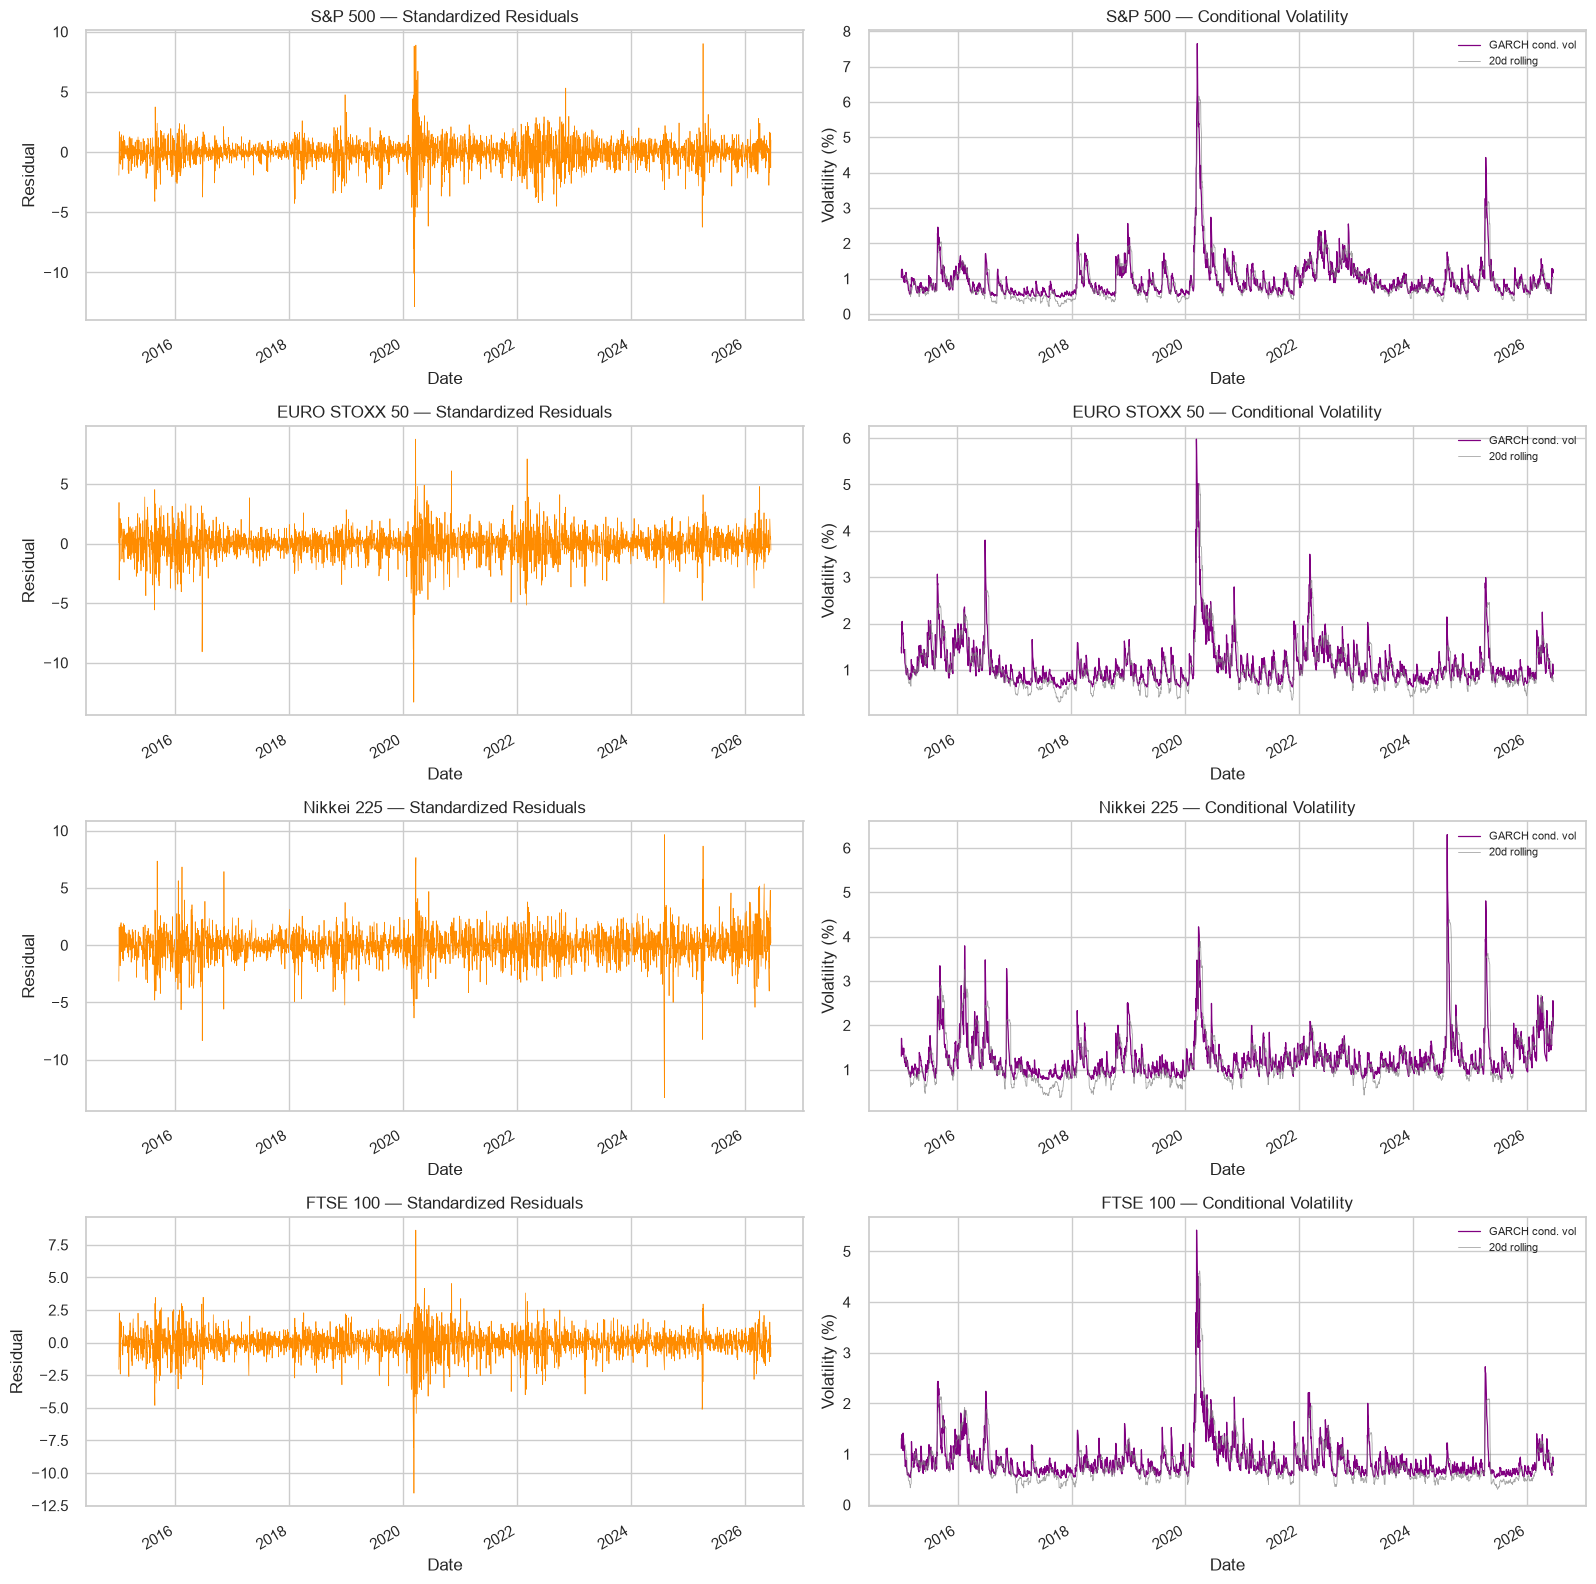


Ljung-Box Test on Standardized Residuals (lag=10):
  S&P 500        : p-value = 0.7021  (no significant autocorrelation)
  EURO STOXX 50  : p-value = 0.9973  (no significant autocorrelation)
  Nikkei 225     : p-value = 0.7916  (no significant autocorrelation)
  FTSE 100       : p-value = 0.8259  (no significant autocorrelation)


In [8]:
# 8. Model Evaluation — Residuals, Conditional Volatility & Diagnostics
for name, res in results.items():
    data[name]['cond_vol'] = res.conditional_volatility

fig, axes = plt.subplots(len(results), 2, figsize=(16, 4 * len(results)))

for i, (name, res) in enumerate(results.items()):
    res.resid.plot(ax=axes[i, 0], color='darkorange', linewidth=0.5)
    axes[i, 0].set_title(f'{name} — Standardized Residuals')
    axes[i, 0].set_ylabel('Residual')

    data[name]['cond_vol'].plot(ax=axes[i, 1], color='purple', linewidth=0.9, label='GARCH cond. vol')
    data[name]['rolling_vol_20'].plot(ax=axes[i, 1], color='gray', linewidth=0.6, alpha=0.7, label='20d rolling')
    axes[i, 1].set_title(f'{name} — Conditional Volatility')
    axes[i, 1].set_ylabel('Volatility (%)')
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nLjung-Box Test on Standardized Residuals (lag=10):')
for name, res in results.items():
    std_resid = res.resid / res.conditional_volatility
    lb = acorr_ljungbox(std_resid, lags=[10], return_df=True)
    pval = lb['lb_pvalue'].values[0]
    flag = '(autocorrelation remains)' if pval < 0.05 else '(no significant autocorrelation)'
    print(f'  {name:15s}: p-value = {pval:.4f}  {flag}')

=== GARCH(1,1) Parameter Comparison ===
                omega   alpha    beta  alpha+beta      AIC      BIC
Index                                                              
S&P 500        0.0407  0.1688  0.7975      0.9662  7465.17  7489.03
EURO STOXX 50  0.0638  0.1512  0.8064      0.9576  8409.45  8433.31
Nikkei 225     0.1017  0.1471  0.7982      0.9453  8995.84  9019.59
FTSE 100       0.0600  0.1697  0.7599      0.9295  7088.23  7112.11


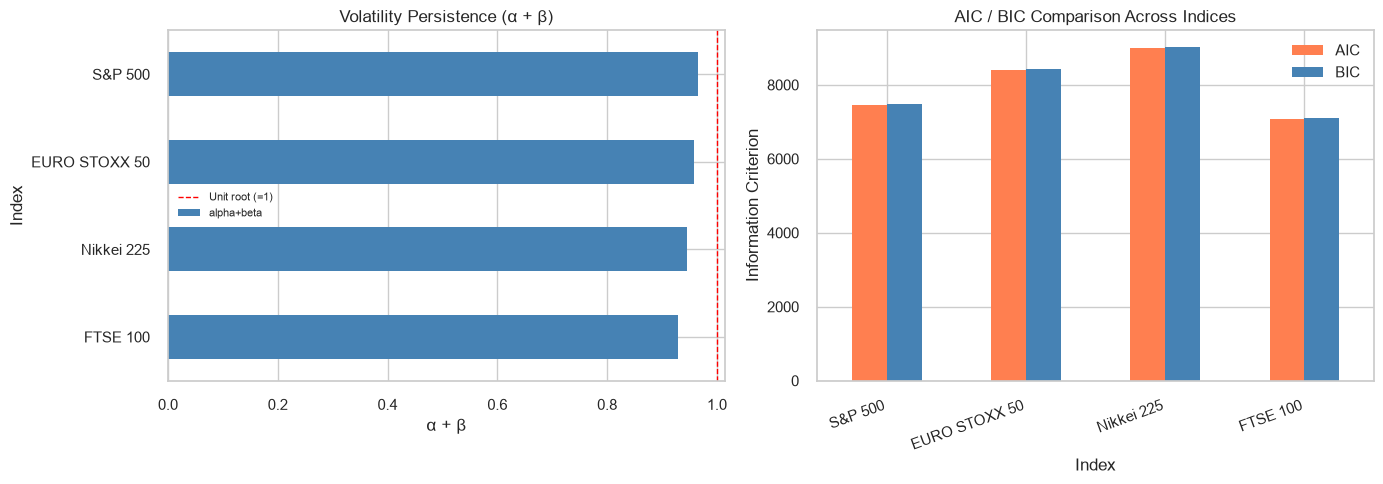

In [9]:
# 9. Results and Comparison

# Parameter comparison table
rows = []
for name, res in results.items():
    p = res.params
    rows.append({
        'Index':      name,
        'omega':      round(p['omega'],    4),
        'alpha':      round(p['alpha[1]'], 4),
        'beta':       round(p['beta[1]'],  4),
        'alpha+beta': round(p['alpha[1]'] + p['beta[1]'], 4),
        'AIC':        round(res.aic, 2),
        'BIC':        round(res.bic, 2),
    })

param_table = pd.DataFrame(rows).set_index('Index')
print('=== GARCH(1,1) Parameter Comparison ===')
print(param_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

param_table['alpha+beta'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='none'
)
axes[0].set_title('Volatility Persistence (α + β)')
axes[0].set_xlabel('α + β')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1, label='Unit root (=1)')
axes[0].legend(fontsize=8)

param_table[['AIC', 'BIC']].plot(
    kind='bar', ax=axes[1], color=['coral', 'steelblue'], edgecolor='none'
)
axes[1].set_title('AIC / BIC Comparison Across Indices')
axes[1].set_ylabel('Information Criterion')
axes[1].set_xticklabels(param_table.index, rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [10]:
# 10. Student-t vs Normal GARCH
print('=== Student-t vs Normal Distribution Comparison ===\n')

st_rows = []
for name, df in data.items():
    res_n = results[name]
    model_t = arch_model(df['return_pct'], vol='Garch', p=1, q=1, dist='t')
    res_t = model_t.fit(disp='off')

    st_rows.append({
        'Index':           name,
        'AIC (Normal)':    round(res_n.aic, 2),
        'AIC (Student-t)': round(res_t.aic, 2),
        'BIC (Normal)':    round(res_n.bic, 2),
        'BIC (Student-t)': round(res_t.bic, 2),
        'Better fit':      'Student-t' if res_t.aic < res_n.aic else 'Normal',
    })

st_table = pd.DataFrame(st_rows).set_index('Index')
print(st_table.to_string())

=== Student-t vs Normal Distribution Comparison ===

               AIC (Normal)  AIC (Student-t)  BIC (Normal)  BIC (Student-t) Better fit
Index                                                                                 
S&P 500             7465.17          7255.37       7489.03          7285.20  Student-t
EURO STOXX 50       8409.45          8190.46       8433.31          8220.28  Student-t
Nikkei 225          8995.84          8821.69       9019.59          8851.37  Student-t
FTSE 100            7088.23          6890.97       7112.11          6920.82  Student-t


In [13]:
# 11. Conclusion
"""
Summary:
- GARCH(1,1) models were fitted to four major global equity indices (S&P 500, EURO STOXX 50,
  Nikkei 225, FTSE 100) over 2015-2026.
- All indices exhibit high volatility persistence (alpha+beta close to 1), confirming that
  volatility shocks die out slowly in equity markets.
- Conditional volatility clearly spikes during crisis periods (e.g. COVID-19 in early 2020).
- The Ljung-Box test checks whether GARCH fully removes autocorrelation in standardized residuals.
- Student-t innovations generally improve fit due to the fat tails in equity returns.
- AIC/BIC enable direct comparison of model quality across both indices and distribution choices.
"""

'\nSummary:\n- GARCH(1,1) models were fitted to four major global equity indices (S&P 500, EURO STOXX 50,\n  Nikkei 225, FTSE 100) over 2015-2026.\n- All indices exhibit high volatility persistence (alpha+beta close to 1), confirming that\n  volatility shocks die out slowly in equity markets.\n- Conditional volatility clearly spikes during crisis periods (e.g. COVID-19 in early 2020).\n- The Ljung-Box test checks whether GARCH fully removes autocorrelation in standardized residuals.\n- Student-t innovations generally improve fit due to the fat tails in equity returns.\n- AIC/BIC enable direct comparison of model quality across both indices and distribution choices.\n'